This notebook for finding best parmter on LSTM

#**Pre-request**

##Mount google drive


In [1]:
### **Mount** Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Install pakages


In [2]:
#Install pakages
project_path = "/content/drive/MyDrive/Sem-6/coding/github/fraud_detection/"
!cat "{project_path}requirement/Install/NASEnhancedPretraindMLModleAdvance.txt"
!pip install  -r "{project_path}requirement/Install/NASEnhancedPretraindMLModleAdvance.txt" --no-cache-dir
%cd $project_path





torch
transformers
huggingface_hub
datasets
timm
patool
sktime
reformer_pytorch
optuna
ptflopsRequirement already satisfied: torch in /usr/local/lib/python3.12/dist-packages (from -r /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/requirement/Install/NASEnhancedPretraindMLModleAdvance.txt (line 1)) (2.11.0+cu128)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.5/37.5 MB 242.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 395.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 379.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 352.4 MB/s eta 0:00:00
/content/drive/MyDrive/Sem-6/coding/github/fraud_detection


##Import  libs

In [3]:
# =====================================================
# 📦 Standard Library
# =====================================================
import os
import sys
import time
import logging
import hashlib
import shutil
import subprocess
import warnings
from datetime import datetime

# Start timer
start_time = time.time()

# =====================================================
# 🧮 Data & Visualization
# =====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# =====================================================
# ⚙️ Machine Learning - Scikit-learn
# =====================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.utils import class_weight
from sklearn.covariance import EmpiricalCovariance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# =====================================================
# 🌲 XGBoost
# =====================================================
from xgboost import XGBClassifier
import joblib

# =====================================================
# 🔥 Deep Learning - PyTorch
# =====================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.cuda.amp import autocast

# =====================================================
# 🤖 Deep Learning - TensorFlow / Keras
# =====================================================
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Masking, Dropout, Layer
from tensorflow.keras.optimizers import Adam

# =====================================================
# 🤗 Transformers & Time Series
# =====================================================
from transformers import AutoModel
from sktime.datasets import load_from_tsfile_to_dataframe
# from mamba_ssm import Mamba  # Uncomment if needed

# =====================================================
# 🧠 Explainability
# =====================================================
import shap

# =====================================================
# 📊 Google Colab Specific
# =====================================================
from google.colab import data_table
data_table.enable_dataframe_formatter()
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
    data_table.DataTable.max_columns = 50
    data_table.DataTable.max_rows = 150
except ImportError:
    pass
from tqdm import tqdm

print("✅ All imports loaded successfully!")

✅ All imports loaded successfully!


##Confirmation setup

In [4]:
# =====================================================
# 🎲 Random Seeds (Reproducibility)
# =====================================================
!nvidia-smi                # confirm GPU
!pip show torch  # confirm versions
torch.manual_seed(42)
np.random.seed(42)

Thu Jul  9 11:30:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             52W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Enable Config

In [5]:

logger = logging.getLogger(__name__)

def load_config(config_path="configs/baseline.yaml"):
    """Load YAML config file and expand ${root_path} placeholders."""
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    logger.info(f"✅ Loaded config from {config_path}")

    # --- Expand ${root_path} placeholders ---
    root = config.get("root_path", "")

    def expand_paths(obj):
        if isinstance(obj, dict):
            return {k: expand_paths(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [expand_paths(i) for i in obj]
        elif isinstance(obj, str) and "${root_path}" in obj:
            return obj.replace("${root_path}", root)
        else:
            return obj

    config = expand_paths(config)
    return config
config = load_config(os.path.join(project_path, "configs", "baseline.yaml"))


## Set Variables

In [6]:


#limit = config['ML']['limit']

# ==========================================================
# UNIFIED HYPERPARAMETERS (Match TimesNet NAS Best)
# ==========================================================
# ==========================================================
# 🔧 UNIFIED HYPERPARAMETERS (Match TimesNet NAS Best)
# ==========================================================

# ----------------------------------------------------------
# 📏 Sequence Settings
# ----------------------------------------------------------
max_seq_len = 6                  # Maximum sequence length
recent_mode = False               # False → oldest mode, True → recent-window mode
n_trials_lstm = 100       # Same as TimesNet NAS (100 trials)
nas_epochs = 20

                       # Maximum training epochs


# ----------------------------------------------------------
# 📊 Evaluation Settings
# ----------------------------------------------------------
opt_metric = "f1"                 # Optimization metric for model selection
correlation_threshold = 0.85      # Feature correlation threshold


# ----------------------------------------------------------
# 💾 Paths
# ----------------------------------------------------------
model_path = config['ML']['models']

# ----------------------------------------------------------
# 🔄 Training State (Reset before each model)
# ----------------------------------------------------------

# ==========================================================
# ✅ Configuration Summary
# ==========================================================
print("="*60)
print("📋 CONFIGURATION SUMMARY")
print("="*60)
print(f"  Sequence length:  {max_seq_len}")
print(f"  Mode:             {'Recent' if recent_mode else 'Oldest'}")
print(f"  Model path:       {model_path}")
print("="*60)

# Global unified results table for all models
results_table = pd.DataFrame(columns=["Round", "AUC", "Recall", "F1", "Model"])
summary = pd.DataFrame(
    columns=[
        "Model",
        "AUC",
        "Recall",
        "Precision",
        "F1",
        "threshold"
    ]
)


📋 CONFIGURATION SUMMARY
  Sequence length:  6
  Mode:             Oldest
  Model path:       /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/models/


##Split users level

In [7]:

# user_path = config['ML']['Events']['base_path'] + config['ML']['Events']['files']['user']
# df_user = pd.read_csv(user_path)
# print(f"✅ Loaded transactional user dataset: {df_user.shape}")



# # Aggregate to one row per user (max label = 1 if any fraud)
# user_labels = df_user.groupby("phone_no_m")["label"].max()
# print(f"👥 Unique users for splitting: {len(user_labels)}")

# # ==============================================================
# # 2️⃣ Create user-level split (stratified, no leakage)
# # ==============================================================

# fraud_users = user_labels[user_labels == 1].index
# normal_users = user_labels[user_labels == 0].index

# fraud_train, fraud_test = train_test_split(fraud_users, test_size=0.2, random_state=42)
# normal_train, normal_test = train_test_split(normal_users, test_size=0.2, random_state=42)

# train_users = set(fraud_train) | set(normal_train)
# test_users  = set(fraud_test)  | set(normal_test)

# # ==============================================================
# # 3️⃣ Save unified split (shared across LSTM / RF / XGB)
# # ==============================================================

# split_dir = "splits/shared_user_split_v1"
# os.makedirs(split_dir, exist_ok=True)

# pd.DataFrame({"phone_no_m": sorted(train_users)}).to_csv(f"{split_dir}/train_users.csv", index=False)
# pd.DataFrame({"phone_no_m": sorted(test_users)}).to_csv(f"{split_dir}/test_users.csv", index=False)

# # ==============================================================
# # 4️⃣ Summary
# # ==============================================================

# print("\n👥 Users Summary:")
# print(f"   Total : {len(user_labels):,}")
# print(f"   Fraud : {len(fraud_users):,} ({len(fraud_users)/len(user_labels)*100:.2f}%)")
# print(f"   Normal: {len(normal_users):,} ({len(normal_users)/len(user_labels)*100:.2f}%)")

# print("\n📂 Split saved to /splits/:")
# print(f"   Train users: {len(train_users)}")
# print(f"   Test  users: {len(test_users)}")
# print(f"   Fraud ratio train: {len(fraud_train)/len(train_users)*100:.2f}%")
# print(f"   Fraud ratio test : {len(fraud_test)/len(test_users)*100:.2f}%")


## Helpers

### evaluate_global

In [8]:
def evaluate_global(model, X_test, y_test, model_name="Model", threshold=0.5):
    """
    Generic evaluator for both classic ML models and neural networks.
    """
    print(f"\n📊 Evaluation threshold is: {threshold}")

    # ---- Predict probabilities ----
    if hasattr(model, "predict_proba"):
        # For sklearn-style models
        y_pred_prob = model.predict_proba(X_test)[:, 1]
    else:
        # For neural nets (e.g., Keras)
        preds = model.predict(X_test)
        if preds.shape[-1] == 2:
            # 2-class softmax output
            y_pred_prob = preds[:, 1]
        else:
            # Single sigmoid output
            y_pred_prob = preds.ravel()

    # ... rest of function unchanged
    # ---- Predict classes ----
    y_pred = (y_pred_prob > threshold).astype(int)

    # ---- Metrics ----
    auc = roc_auc_score(y_test, y_pred_prob)
    #recall = recall_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, zero_division=0)

    precision = precision_score(y_test, y_pred, zero_division=0)
    #f1 = f1_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, zero_division=0)

    report = classification_report(y_test, y_pred, digits=4)
    cm = confusion_matrix(y_test, y_pred)

    # ---- Display ----
    print(f"\n📊 Classification Report — {model_name}")
    print(report)
    print(f"AUC: {auc:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f} | F1: {f1:.4f}")

    # ---- Confusion Matrix ----
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Fraud (1)"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.grid(False)
    plt.show()

    # ---- Summary Dictionary ----
    return {
        "Model": model_name,
        "AUC": auc,
        "Recall": recall,
        "Precision": precision,
        "F1": f1,
        "threshold": threshold
    }



### append_to_summary

In [9]:

def append_to_summary(summary, model_name, results):
    """
    Appends or updates the summary table with model results.
    Works with both capitalized and lowercase keys automatically.
    """
    # ✅ Create summary DataFrame if missing
    if summary is None or not isinstance(summary, pd.DataFrame):
          summary = pd.DataFrame(columns=["Model", "AUC", "Recall", "Precision", "F1", "Threshold"])
    # Ensure "Model" column exists (prevents KeyError)
    if "Model" not in summary.columns:
        summary = pd.DataFrame(columns=["Model", "AUC", "Recall", "Precision", "F1", "Threshold"])

    # ✅ Normalize key names to lowercase
    results = {k.lower(): v for k, v in results.items()}

    # ✅ Remove any existing row for the same model
    summary = summary[summary["Model"] != model_name]

    # ✅ Add new row (robust to missing values)
    row = {
        "Model": model_name,
        "AUC": round(results.get("auc", np.nan), 4) if not pd.isna(results.get("auc", np.nan)) else np.nan,
        "Recall": round(results.get("recall", np.nan), 4) if not pd.isna(results.get("recall", np.nan)) else np.nan,
        "Precision": round(results.get("precision", np.nan), 4) if not pd.isna(results.get("precision", np.nan)) else np.nan,
        "F1": round(results.get("f1", np.nan), 4) if not pd.isna(results.get("f1", np.nan)) else np.nan,
        "Threshold": round(results.get("threshold", np.nan), 4) if not pd.isna(results.get("threshold", np.nan)) else np.nan
    }


    # ✅ Append and reindex
    summary = pd.concat([summary, pd.DataFrame([row])], ignore_index=True)
    summary = summary.reindex(columns=["Model", "AUC", "Recall", "Precision", "F1", "Threshold"])
    return summary


### find_best_threshold

In [10]:
def find_best_threshold(y_true, probs, low=0.2, high=0.8, n=61):
    best_f1 = -1.0
    best_thr = 0.5
    for thr in np.linspace(low, high, n):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr, best_f1

###Drop and select features

In [11]:
def prepare_features(df):
    """
    Selects only the explicitly defined features for model training.
    You control which features are used by editing 'selected_features' below.
    """

    # --- Define selected features manually ---
    selected_features = [
        "window_size", "voc_total_calls", "voc_unique_contacts", "voc_total_duration",
       "voc_avg_duration", "voc_max_duration", "voc_std_duration", "voc_active_days",
       "voc_active_hours", "sms_total_msgs", "sms_unique_contacts", "sms_active_hours",
       "sms_calltype_ratio", "app_months_active", "app_total_flow", "app_avg_flow",
       "app_std_flow", "app_unique_apps_mean", "app_unique_apps_max", "user_months_active",
        "arpu_mean", "arpu_std", "arpu_max", "idcard_cnt", "snapshot_round"
   ]
  #  selected_features = [
   #     "voc_total_calls", "voc_unique_contacts", "voc_total_duration",
    #   "voc_avg_duration", "voc_max_duration", "voc_std_duration", "voc_active_days",
     # "voc_active_hours", "sms_total_msgs", "sms_unique_contacts", "sms_active_hours",
     #"sms_calltype_ratio", "idcard_cnt"
    #]
   # selected_features = [
    #    "voc_active_days",
    #"voc_active_hours",
    #"voc_unique_contacts",
    #"sms_calltype_ratio",
    #"sms_active_hours" ]


    # ✅ You can manually remove or comment out features here
    # For example:
    # selected_features = [f for f in selected_features if not (f.startswith("app_") or f.startswith("arpu_"))]

    # --- Keep only existing columns ---
    available = [f for f in selected_features if f in df.columns]
    missing = [f for f in selected_features if f not in df.columns]

    X = df[available].copy()

    #print(f"\n📊 Final features used ({len(available)}): {available}")
    if missing:
        print(f"⚠️ Missing columns not found in data: {missing}")

    return X


### Compare

In [12]:

def plot_progressive_results(
    results_table,
    metrics=("AUC", "Recall", "F1"),
    round_col=None,
    figsize=(14, 6)
):
    """
    Plot progressive evaluation metrics per round for multiple models.

    Parameters
    ----------
    results_table : pd.DataFrame
        Must contain columns: Model, metrics, and either Round or input_size
    metrics : tuple
        Metrics to plot (default: AUC, Recall, F1)
    round_col : str or None
        Column name for x-axis. If None, auto-detects.
    figsize : tuple
        Figure size for plots
    """

    # --------------------------------------------------
    # Auto-detect round column
    # --------------------------------------------------
    if round_col is None:
        if "Round" in results_table.columns:
            round_col = "Round"
        elif "input_size" in results_table.columns:
            round_col = "input_size"
        else:
            raise ValueError("No Round or input_size column found.")

    # --------------------------------------------------
    # Sort results (important for correct curves)
    # --------------------------------------------------
    results_table = results_table.sort_values(
        by=[round_col, "Model"],
        ascending=True
    ).reset_index(drop=True)


    # --------------------------------------------------
    # Plot each metric
    # --------------------------------------------------
    for metric in metrics:

        plt.figure(figsize=figsize)

        for model in results_table["Model"].unique():
            subset = (
                results_table[results_table["Model"] == model]
                .sort_values(by=round_col)
            )

            plt.plot(
                subset[round_col],
                subset[metric],
                marker="o",
                markersize=6,
                linewidth=2,
                label=model,
                alpha=0.85
            )

        plt.title(f"{metric} per {round_col}", fontsize=18)
        plt.xlabel(round_col, fontsize=14)
        plt.ylabel(metric, fontsize=14)
        plt.grid(True, linestyle="--", alpha=0.4)

        # Legend outside
        plt.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.12),
            ncol=4,
            fontsize=10
        )

        plt.tight_layout(rect=[0, 0.1, 1, 1])
        plt.show()
    display(results_table)

    return results_table


###get_key_rounds

In [13]:
# ============================================================
# 🔬 SCIENTIFIC KEY ROUNDS SELECTION
# ============================================================

def get_key_rounds(max_seq_len, method="linear", n_points=5):
    """
    Generate scientifically meaningful evaluation checkpoints.

    Args:
        max_seq_len: Maximum sequence length (16, 100, 300, etc.)
        method: Selection strategy
            - "linear": Equal spacing (1, 25%, 50%, 75%, 100%)
            - "logarithmic": More points early (where changes happen fast)
            - "sqrt": Square root spacing (balanced)
            - "percentile": Fixed percentages
        n_points: Number of evaluation points (default 5)

    Returns:
        List of round numbers to evaluate
    """

    if max_seq_len <= n_points:
        # If sequence is short, evaluate all rounds
        return list(range(1, max_seq_len + 1))

    if method == "linear":
        # Equal spacing: 1, 25%, 50%, 75%, 100%
        rounds = np.linspace(1, max_seq_len, n_points)

    elif method == "logarithmic":
        # More points early (fraud detection often shows early signal)
        # Log scale: 1, 2, 4, 8, 16 style
        rounds = np.logspace(0, np.log10(max_seq_len), n_points)

    elif method == "sqrt":
        # Square root spacing (balanced between linear and log)
        rounds = np.square(np.linspace(1, np.sqrt(max_seq_len), n_points))

    elif method == "percentile":
        # Fixed percentages: 1st event, 10%, 25%, 50%, 75%, 100%
        percentages = [0, 0.1, 0.25, 0.5, 0.75, 1.0]
        rounds = [max(1, int(p * max_seq_len)) for p in percentages]
        return sorted(set(rounds))  # Remove duplicates

    elif method == "early_focus":
        # Focus on early detection (more points in first half)
        # Useful for fraud detection where early signal matters
        early = np.linspace(1, max_seq_len * 0.5, n_points - 2)
        late = [max_seq_len * 0.75, max_seq_len]
        rounds = np.concatenate([early, late])

    else:
        raise ValueError(f"Unknown method: {method}")

    # Convert to integers, ensure valid range, remove duplicates
    rounds = [int(round(r)) for r in rounds]
    rounds = [max(1, min(r, max_seq_len)) for r in rounds]
    rounds = sorted(set(rounds))

    # Always include 1 and max_seq_len
    if 1 not in rounds:
        rounds = [1] + rounds
    if max_seq_len not in rounds:
        rounds = rounds + [max_seq_len]

    return rounds

##key_rounds = get_key_rounds(max_seq_len, method=method, n_points=n_points)
##print(f"📊 Evaluating rounds: {key_rounds}")
#print(f"   Total: {len(key_rounds)} rounds instead of {max_seq_len}")

#ML Modules

### Feature Importance

In [14]:
# def plot_feature_importance(model, X_train, model_name="Model", top_n=20):
#     """
#     Plot feature importance for tree-based models (XGBoost, RandomForest).
#     """


#     # Handle model type
#     if hasattr(model, "get_booster"):  # XGBoost
#         importance = model.get_booster().get_score(importance_type='gain')
#         fi = pd.DataFrame({
#             'Feature': list(importance.keys()),
#             'Importance': list(importance.values())
#         })
#     elif hasattr(model, "feature_importances_"):  # RandomForest
#         fi = pd.DataFrame({
#             'Feature': X_train.columns,
#             'Importance': model.feature_importances_
#         })
#     else:
#         raise ValueError(f"{model_name} does not support feature importance extraction.")

#     # Sort and plot
#     fi = fi.sort_values(by='Importance', ascending=False)
#     display(fi.head(10))

#     plt.figure(figsize=(10,6))
#     plt.barh(fi['Feature'][:top_n][::-1], fi['Importance'][:top_n][::-1])
#     plt.title(f'📊 {model_name} Feature Importance (Top {top_n})')
#     plt.xlabel('Importance')
#     plt.ylabel('Feature')
#     plt.grid(alpha=0.4)
#     plt.tight_layout()
#     plt.show()

#     return fi

# fi_xgb = plot_feature_importance(xgb_model, snap_X_train, "XGBoost")
# fi_rf = plot_feature_importance(rf_model, snap_X_train, "Random Forest")


### Load

In [15]:
def load_raw_datasets(config):


    if "ML" in config and "Events" in config["ML"]:
        events_cfg = config["ML"]["Events"]
    else:
        events_cfg = config["Events"]

    base = events_cfg["base_path"]
    files = events_cfg["files"]

    # --- Load all datasets ---
    df_voc = pd.read_csv(os.path.join(base, files["voc"]))
    df_sms = pd.read_csv(os.path.join(base, files["sms"]))
    df_app = pd.read_csv(os.path.join(base, files["app"]))
    df_user = pd.read_csv(os.path.join(base, files["user"]))

    # --- Normalize timestamps and add source column ---
    for df, src in [(df_voc, "VOC"), (df_sms, "SMS"), (df_app, "APP"), (df_user, "USER")]:
        df["source"] = src
        ts_col = [c for c in df.columns if "time" in c.lower()][0]
        df.rename(columns={ts_col: "event_time"}, inplace=True)
        df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")

    print("✅ Raw datasets loaded and timestamp-normalized.")
    return df_voc, df_sms, df_app, df_user

df_voc, df_sms, df_app, df_user = load_raw_datasets(config)


✅ Raw datasets loaded and timestamp-normalized.


### Build timeline (events)

In [16]:
def merge_and_prepare_events(df_voc, df_sms, df_app, df_user):

    # --- 1️⃣ Normalize USER dataset ---
    if 'label' not in df_user.columns:
        raise KeyError("❌ 'label' column not found in user dataset")

    # Ensure numeric consistency
    df_user['label'] = df_user['label'].fillna(0).astype(int)
    df_user['idcard_cnt'] = df_user['idcard_cnt'].fillna(0).astype(float)
    df_user['arpu_value'] = df_user['arpu_value'].fillna(0).astype(float)

    # --- 2️⃣ Extract static info for merging (label + sim count only) ---
    #static_user_info = df_user.groupby("phone_no_m", as_index=False)[["label", "idcard_cnt"]].max()
    # --- 2️⃣ Extract static info from the RAW user table (covers all 6,106 users) ---
    lbl_cfg = config["ML"]["labels"]
    raw_user = pd.read_csv(os.path.join(lbl_cfg["base_path"], lbl_cfg["file"]))
    static_user_info = raw_user[["phone_no_m", "label", "idcard_cnt"]].drop_duplicates("phone_no_m")
    static_user_info["label"] = static_user_info["label"].astype(int)
    static_user_info["idcard_cnt"] = static_user_info["idcard_cnt"].fillna(0).astype(float)

    # --- 3️⃣ Merge static info into other event tables ---
    df_voc = df_voc.merge(static_user_info, on="phone_no_m", how="left")
    df_sms = df_sms.merge(static_user_info, on="phone_no_m", how="left")
    df_app = df_app.merge(static_user_info, on="phone_no_m", how="left")


    # --- 4️⃣ Combine all transactional event sources ---
    # include df_user itself since arpu_value is event-like
    events = pd.concat([df_voc, df_sms, df_app, df_user], ignore_index=True)

    # --- 5️⃣ Fill and order ---
    #events["label"] = events["label"].fillna(0).astype(int)
    missing = int(events["label"].isna().sum())
    assert missing == 0, f"{missing} events have no label — label merge is broken"
    events["label"] = events["label"].astype(int)

    events["event_time"] = pd.to_datetime(events["event_time"], errors="coerce")
    events = events.sort_values(["phone_no_m", "event_time"]).reset_index(drop=True)

    # --- 6️⃣ Summary ---
    print("\n🔎 Feature Summary per Source:")
    for src, df in [("VOC", df_voc), ("SMS", df_sms), ("APP", df_app), ("USER", df_user)]:
        print(f"\n📂 Source: {src}")
        print(f"   Events: {len(df):,}")
        print(f"   Users : {df['phone_no_m'].nunique():,}")
        print(f"   Columns ({len(df.columns)}): {', '.join(df.columns)}")

    print("\n📊 Combined Dataset Summary:")
    print(f"   Total events: {len(events):,}")
    print(f"   Unique users: {events['phone_no_m'].nunique():,}")
    print(f"   Fraud ratio: {events['label'].mean()*100:.2f}%")
    user_labels = events.groupby("phone_no_m")["label"].max()
    print(f"   Fraud users: {int(user_labels.sum()):,} / {user_labels.size:,} ({user_labels.mean()*100:.2f}%)")

    return events

events = merge_and_prepare_events(df_voc, df_sms, df_app, df_user)

display(events.head())


🔎 Feature Summary per Source:

📂 Source: VOC
   Events: 5,015,430
   Users : 6,025
   Columns (11): phone_no_m, opposite_no_m, calltype_id, event_time, call_dur, city_name, county_name, imei_m, source, label, idcard_cnt

📂 Source: SMS
   Events: 6,848,509
   Users : 6,103
   Columns (7): phone_no_m, opposite_no_m, calltype_id, event_time, source, label, idcard_cnt

📂 Source: APP
   Events: 3,283,602
   Users : 6,106
   Columns (10): phone_no_m, event_time, source, busi_name, flow, month_id, flow_norm, month_str, label, idcard_cnt

📂 Source: USER
   Events: 39,454
   Users : 5,929
   Columns (10): phone_no_m, event_time, source, month_id, arpu_value, city_name, county_name, idcard_cnt, label, month_col

📊 Combined Dataset Summary:
   Total events: 15,186,995
   Unique users: 6,106
   Fraud ratio: 24.63%
   Fraud users: 1,962 / 6,106 (32.13%)


,phone_no_m,opposite_no_m,calltype_id,event_time,call_dur,city_name,county_name,imei_m,source,label,idcard_cnt,busi_name,flow,month_id,flow_norm,month_str,arpu_value,month_col
0,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-12 08:09:11,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-13 16:21:53,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00073ceecc0f7220a440580ac5dea410c90d14b6669458...,df22edbc0e3dd6bc4f2f453e687b743e8442a54834b64f...,2.0,2019-08-13 16:21:53,NaN,NaN,NaN,NaN,SMS,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Split data based on users (fraud, not fraud)

In [17]:


# ======================================
# Clean Numeric Columns
# ======================================
events = events.copy()
numeric_cols = events.select_dtypes(include=["number"]).columns.difference(["label"])

# Replace NaN with 0 for numeric fields (avoids scaling issues)
events[numeric_cols] = events[numeric_cols].fillna(0)

print(f"\n📊 Numeric columns to scale ({len(numeric_cols)}): {numeric_cols.tolist()}")


# ======================================
# 2 Create / Load Shared Train-Val-Test User Split
# ======================================
split_dir = os.path.join(config["root_path"], "splits", "shared_user_split_v1")
train_split_file = f"{split_dir}/train_users.csv"
test_split_file  = f"{split_dir}/test_users.csv"
val_split_file   = f"{split_dir}/val_users.csv"

os.makedirs(split_dir, exist_ok=True)

all_split_files_exist = (
    os.path.exists(train_split_file)
    and os.path.exists(test_split_file)
    and os.path.exists(val_split_file)
)

if all_split_files_exist:
    print("📂 Using shared user split files...")
    train_users = set(pd.read_csv(train_split_file)["phone_no_m"])
    test_users  = set(pd.read_csv(test_split_file)["phone_no_m"])
    val_users   = set(pd.read_csv(val_split_file)["phone_no_m"])
else:
    print("🆕 Creating shared train/test/val user split...")

    # One label per user
    user_labels = events.groupby("phone_no_m")["label"].max()
    fraud_users = user_labels[user_labels == 1].index
    normal_users = user_labels[user_labels == 0].index

    # 1) Train/Test split (split fraud user %)
    fraud_train, fraud_test = train_test_split(
        fraud_users, test_size=0.2, random_state=42
    )
    normal_train, normal_test = train_test_split(
        normal_users, test_size=0.2, random_state=42
    )

    train_users_full = set(fraud_train) | set(normal_train)
    test_users = set(fraud_test) | set(normal_test)

    # 2) Validation split from training users only
    train_user_labels = user_labels.loc[list(train_users_full)]

    fraud_train_users = train_user_labels[train_user_labels == 1].index
    normal_train_users = train_user_labels[train_user_labels == 0].index

    fraud_tr, fraud_val = train_test_split(
        fraud_train_users, test_size=0.2, random_state=42
    )
    normal_tr, normal_val = train_test_split(
        normal_train_users, test_size=0.2, random_state=42
    )

    train_users = set(fraud_tr) | set(normal_tr)
    val_users   = set(fraud_val) | set(normal_val)

    pd.DataFrame({"phone_no_m": sorted(train_users)}).to_csv(train_split_file, index=False)
    pd.DataFrame({"phone_no_m": sorted(test_users)}).to_csv(test_split_file, index=False)
    pd.DataFrame({"phone_no_m": sorted(val_users)}).to_csv(val_split_file, index=False)

    print(f"✅ Saved shared split files to '{split_dir}/'")
# ======================================
# Split overlap checks
# ======================================
assert len(train_users & test_users) == 0, "❌ User leakage: train and test overlap"
assert len(train_users & val_users) == 0, "❌ User leakage: train and val overlap"
assert len(test_users & val_users) == 0, "❌ User leakage: test and val overlap"

print("🔒 Split overlap checks passed:")
print(f"   train ∩ test = {len(train_users & test_users)}")
print(f"   train ∩ val  = {len(train_users & val_users)}")
print(f"   test  ∩ val  = {len(test_users & val_users)}")
user_labels = events.groupby("phone_no_m")["label"].max()
print(f"   sizes  train/val/test = {len(train_users)} / {len(val_users)} / {len(test_users)}")
print(f"   fraud  train/val/test = {int(user_labels.loc[list(train_users)].sum())} / "
      f"{int(user_labels.loc[list(val_users)].sum())} / {int(user_labels.loc[list(test_users)].sum())}")
# ======================================
# Apply Split to Events
# ======================================
train_events = events[events["phone_no_m"].isin(train_users)]
test_events  = events[events["phone_no_m"].isin(test_users)]
val_events = events[events["phone_no_m"].isin(val_users)]

# Sanity checks
assert len(set(train_events["phone_no_m"]) & set(test_events["phone_no_m"])) == 0, "❌ User leakage detected!"
assert train_events["label"].nunique() == 2, "❌ Training set must contain both classes"
assert test_events["label"].nunique() == 2, "❌ Test set must contain both classes"

# --- add time gap, scaled featur ---
# for name, df in [('train_events', train_events), ('test_events', test_events)]:
#     df = df.copy()  # avoid SettingWithCopyWarning
#     df['event_time'] = pd.to_datetime(df['event_time'])
#     #df.sort_values(['phone_no_m', 'event_time'], inplace=True)
#     df = df.sort_values(['phone_no_m', 'event_time'], kind='mergesort').reset_index(drop=True)
#     df['dt_hours'] = df.groupby('phone_no_m')['event_time'].diff().dt.total_seconds() / 3600
#     df['dt_hours'] = df['dt_hours'].fillna(0)
#     df['dt_hours'] = np.log1p(df['dt_hours'])  # normalize gaps
#     if name == 'train_events':
#         train_events = df
#     else:
#         test_events = df
for name, df in [
    ('train_events', train_events),
    ('val_events', val_events),
    ('test_events', test_events)
]:
    df = df.copy()
    df['event_time'] = pd.to_datetime(df['event_time'])
    df = df.sort_values(['phone_no_m', 'event_time'], kind='mergesort').reset_index(drop=True)
    df['dt_hours'] = df.groupby('phone_no_m')['event_time'].diff().dt.total_seconds() / 3600
    df['dt_hours'] = df['dt_hours'].fillna(0)
    df['dt_hours'] = np.log1p(df['dt_hours'])

    if name == 'train_events':
        train_events = df
    elif name == 'val_events':
        val_events = df
    else:
        test_events = df


# Store unscaled events BEFORE line 895
train_events_unscaled = train_events.copy()
test_events_unscaled = test_events.copy()
val_events_unscaled = val_events.copy()


# Sanity checks
assert len(set(train_events["phone_no_m"]) & set(test_events["phone_no_m"])) == 0, "❌ User leakage detected!"
assert train_events["label"].nunique() == 2, "❌ Training set must contain both classes"
assert test_events["label"].nunique() == 2, "❌ Test set must contain both classes"
scale_cols_seq = sorted(set(train_events.select_dtypes(include=["number"]).columns) - {"label"})
scaler_seq = StandardScaler().fit(train_events[scale_cols_seq])
train_events[scale_cols_seq] = scaler_seq.transform(train_events[scale_cols_seq])
test_events[scale_cols_seq]  = scaler_seq.transform(test_events[scale_cols_seq])
val_events[scale_cols_seq]   = scaler_seq.transform(val_events[scale_cols_seq])

# ======================================
# 4️⃣ snapshot
# ======================================

# ======================================
# 4️⃣ Create Sequences (using multiple features)
# ======================================
numeric_features = [c for c in numeric_cols if c not in ["label"]]  # exclude label
if 'dt_hours' in train_events.columns:
    numeric_features.append('dt_hours')
print(f"\n📦 Features used for sequences: {numeric_features}")
feature_cols_tf = numeric_features.copy()
# 👉 Transformer feature columns: same numeric features as LSTM + source_id

if "source_id" not in feature_cols_tf:
    feature_cols_tf.append("source_id")

print("[Transformer] feature_cols_tf:", feature_cols_tf)



📊 Numeric columns to scale (6): ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt']
📂 Using shared user split files...
🔒 Split overlap checks passed:
   train ∩ test = 0
   train ∩ val  = 0
   test  ∩ val  = 0
   sizes  train/val/test = 3907 / 977 / 1222
   fraud  train/val/test = 1255 / 314 / 393

📦 Features used for sequences: ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt', 'dt_hours']
[Transformer] feature_cols_tf: ['arpu_value', 'call_dur', 'calltype_id', 'flow', 'flow_norm', 'idcard_cnt', 'dt_hours', 'source_id']


### Generate_snapshots_from_events

In [18]:
# ============================================================
# 🔧 OPTIMIZED SNAPSHOT GENERATION FROM EVENTS (FIXED)
# ============================================================

def generate_snapshots_from_events(
    events_df,
    users,
    r,
    max_seq_len,
    recent_mode=True
):
    """
    Generate snapshot features from events DataFrame.
    OPTIMIZED: Uses groupby instead of per-user filtering.
    """

    # 1️⃣ Filter to relevant users FIRST (huge speedup)
    events_filtered = events_df[events_df["phone_no_m"].isin(users)].copy()

    if events_filtered.empty:
        return pd.DataFrame(), np.array([]), np.array([])

    # 2️⃣ Sort once
    events_filtered = events_filtered.sort_values(["phone_no_m", "event_time"])

    # 3️⃣ Apply selection logic per user using groupby
    def select_events(df_u):
        if recent_mode:
            df_u = df_u.tail(max_seq_len).head(r)
        else:
            df_u = df_u.head(r)
        return df_u

    selected = events_filtered.groupby("phone_no_m", group_keys=False).apply(select_events)

    if selected.empty:
        return pd.DataFrame(), np.array([]), np.array([])

    # 4️⃣ Aggregate features using groupby
    snapshot_rows = []

    for user, df_u in tqdm(selected.groupby("phone_no_m"), desc="Generating snapshots"):
    #for user, df_u in selected.groupby("phone_no_m"):
        row = {"phone_no_m": user}

        # Get label
        label = int(df_u["label"].max()) if "label" in df_u.columns else 0

        # --- Voice Features ---
        voc = df_u[df_u["source"] == "VOC"]
        if len(voc) > 0:
            if "call_dur" in voc.columns:
                call_dur = pd.to_numeric(voc["call_dur"], errors="coerce").fillna(0)
            else:
                call_dur = pd.Series([0])

            row["voc_total_calls"] = len(voc)
            row["voc_unique_contacts"] = voc["opposite_no_m"].nunique() if "opposite_no_m" in voc.columns else 0
            row["voc_total_duration"] = call_dur.sum()
            row["voc_avg_duration"] = call_dur.mean()
            row["voc_max_duration"] = call_dur.max()
            row["voc_std_duration"] = call_dur.std() if len(call_dur) > 1 else 0
            row["voc_active_days"] = voc["event_time"].dt.weekday.nunique()
            row["voc_active_hours"] = voc["event_time"].dt.hour.nunique()
        else:
            row.update({
                "voc_total_calls": 0, "voc_unique_contacts": 0, "voc_total_duration": 0,
                "voc_avg_duration": 0, "voc_max_duration": 0, "voc_std_duration": 0,
                "voc_active_days": 0, "voc_active_hours": 0
            })

        # --- SMS Features ---
        sms = df_u[df_u["source"] == "SMS"]
        if len(sms) > 0:
            row["sms_total_msgs"] = len(sms)
            row["sms_unique_contacts"] = sms["opposite_no_m"].nunique() if "opposite_no_m" in sms.columns else 0
            row["sms_active_hours"] = sms["event_time"].dt.hour.nunique()
            if "calltype_id" in sms.columns:
                calltype = pd.to_numeric(sms["calltype_id"], errors="coerce")
                row["sms_calltype_ratio"] = (calltype == 1).mean()
            else:
                row["sms_calltype_ratio"] = 0
        else:
            row.update({
                "sms_total_msgs": 0, "sms_unique_contacts": 0,
                "sms_active_hours": 0, "sms_calltype_ratio": 0
            })

        # --- App Features ---
        app = df_u[df_u["source"] == "APP"]
        if len(app) > 0:
            if "flow" in app.columns:
                flow = pd.to_numeric(app["flow"], errors="coerce").fillna(0)
            else:
                flow = pd.Series([0])

            row["app_months_active"] = app["month_id"].nunique() if "month_id" in app.columns else 0
            row["app_total_flow"] = flow.sum()
            row["app_avg_flow"] = flow.mean()
            row["app_std_flow"] = flow.std() if len(flow) > 1 else 0
            row["app_unique_apps_mean"] = app["busi_name"].nunique() if "busi_name" in app.columns else 0
            row["app_unique_apps_max"] = app["busi_name"].nunique() if "busi_name" in app.columns else 0
        else:
            row.update({
                "app_months_active": 0, "app_total_flow": 0, "app_avg_flow": 0,
                "app_std_flow": 0, "app_unique_apps_mean": 0, "app_unique_apps_max": 0
            })

        # --- User/ARPU Features ---
        arpu = df_u[df_u["source"] == "USER"]
        if len(arpu) > 0:
            if "arpu_value" in arpu.columns:
                arpu_val = pd.to_numeric(arpu["arpu_value"], errors="coerce")
            else:
                arpu_val = pd.Series([0])

            row["user_months_active"] = arpu["month_id"].nunique() if "month_id" in arpu.columns else 0
            row["arpu_mean"] = arpu_val.mean()
            row["arpu_std"] = arpu_val.std() if len(arpu_val) > 1 else 0
            row["arpu_max"] = arpu_val.max()
            row["idcard_cnt"] = arpu["idcard_cnt"].max() if "idcard_cnt" in arpu.columns else 0
        else:
            row.update({
                "user_months_active": 0, "arpu_mean": 0, "arpu_std": 0,
                "arpu_max": 0, "idcard_cnt": 0
            })

        # Meta features
        row["window_size"] = r
        row["snapshot_round"] = r
        row["label"] = label

        snapshot_rows.append(row)

    # Build DataFrame
    df_snapshot = pd.DataFrame(snapshot_rows).fillna(0)

    if df_snapshot.empty:
        return pd.DataFrame(), np.array([]), np.array([])

    y = df_snapshot["label"].values
    user_ids = df_snapshot["phone_no_m"].values
    X = df_snapshot.drop(columns=["phone_no_m", "label"])

    return X, y, user_ids



#  ▶ Classic Ml Snapshot based

###### Genrate input data

In [19]:

# ============================================================
# 📋 Define snapshot feature columns (same as sequencestreaming.py)
# ============================================================

SNAPSHOT_FEATURE_COLS = [
    # Voice
    "voc_total_calls", "voc_unique_contacts", "voc_total_duration",
    "voc_avg_duration", "voc_max_duration", "voc_std_duration",
    "voc_active_days", "voc_active_hours",
    # SMS
    "sms_total_msgs", "sms_unique_contacts", "sms_active_hours", "sms_calltype_ratio",
    # App
    "app_months_active", "app_total_flow", "app_avg_flow",
    "app_std_flow", "app_unique_apps_mean", "app_unique_apps_max",
    # User / ARPU
    "user_months_active", "arpu_mean", "arpu_std", "arpu_max", "idcard_cnt",
    # Meta
    "window_size", "snapshot_round"
]

print(f"📊 Snapshot features: {len(SNAPSHOT_FEATURE_COLS)} columns")

# ============================================================
# 🚀 RF/XGBoost - UNIFIED PIPELINE (Uses same events as LSTM)
# ============================================================


print("\n" + "="*60)
print(f"[{datetime.now()}] 🌲 RF/XGBoost Training (from events, same as LSTM)")
print("="*60)

# ============================================================
# 1️⃣ Generate training snapshots (r = max_seq_len)
# ============================================================
print(f"\n[{datetime.now()}] 📊 Generating training snapshots (r={max_seq_len})...")

X_train_snap, y_train_snap, users_train_snap = generate_snapshots_from_events(
    events_df=train_events_unscaled,
    users=train_users,
    r=max_seq_len,
    max_seq_len=max_seq_len,
    recent_mode=recent_mode
)

print(f"[{datetime.now()}] ✅ Training snapshots: {len(X_train_snap)} users, {X_train_snap.shape[1]} features")

# ============================================================
# 2️⃣ Align columns and scale
# ============================================================
print(f"[{datetime.now()}] 🔄 Scaling...")
X_train_snap = X_train_snap.reindex(columns=SNAPSHOT_FEATURE_COLS, fill_value=0)
scaler_snap = StandardScaler().fit(X_train_snap)
X_train_scaled = scaler_snap.transform(X_train_snap)
print(f"[{datetime.now()}] ✅ Scaling done")


📊 Snapshot features: 25 columns

[2026-07-09 11:33:17.473340] 🌲 RF/XGBoost Training (from events, same as LSTM)

[2026-07-09 11:33:17.473430] 📊 Generating training snapshots (r=6)...


/tmp/ipykernel_2385/10258993.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selected = events_filtered.groupby("phone_no_m", group_keys=False).apply(select_events)
Generating snapshots: 100%|██████████| 3907/3907 [00:11<00:00, 331.20it/s]


[2026-07-09 11:33:45.802511] ✅ Training snapshots: 3907 users, 25 features
[2026-07-09 11:33:45.802667] 🔄 Scaling...
[2026-07-09 11:33:45.808218] ✅ Scaling done


#### Show sample

In [20]:
# ============================================================
# 🔍 DEBUG: Print Sample Snapshots
# ============================================================

print("="*60)
print("🔍 SAMPLE SNAPSHOTS DEBUG")
print("="*60)

# Generate a small sample
X_sample, y_sample, users_sample = generate_snapshots_from_events(
    events_df=train_events_unscaled,
    users=list(train_users)[:10],  # Only 10 users for sample
    r=max_seq_len,
    max_seq_len=max_seq_len,
    recent_mode=recent_mode
)

print(f"\n📊 Sample shape: {X_sample.shape}")
print(f"📊 Labels: {y_sample}")
print(f"📊 Users: {users_sample}")

# Show features
print(f"\n📋 Feature columns ({len(X_sample.columns)}):")
print(X_sample.columns.tolist())

# Show sample data
print(f"\n📊 Sample snapshots (first 5 users):")
sample_df = X_sample.copy()
sample_df['label'] = y_sample
sample_df['user'] = users_sample
sample_df = sample_df[['user', 'label'] + [c for c in sample_df.columns if c not in ['user', 'label']]]
display(sample_df.head())

# Show statistics
print(f"\n📈 Feature statistics:")
display(X_sample.describe().T)

# Show class distribution
print(f"\n📊 Class distribution:")
print(f"   Fraud (1): {sum(y_sample == 1)} ({sum(y_sample == 1)/len(y_sample)*100:.1f}%)")
print(f"   Normal (0): {sum(y_sample == 0)} ({sum(y_sample == 0)/len(y_sample)*100:.1f}%)")

🔍 SAMPLE SNAPSHOTS DEBUG


/tmp/ipykernel_2385/10258993.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selected = events_filtered.groupby("phone_no_m", group_keys=False).apply(select_events)
Generating snapshots: 100%|██████████| 10/10 [00:00<00:00, 282.41it/s]


📊 Sample shape: (10, 25)
📊 Labels: [0 1 1 0 0 1 0 0 0 0]
📊 Users: ['0069597773dc9bf2bfd586a510a1df1fb431456bdd98c5b380887cba8d5372dd87fb436d6ca32c72d789cabe619c28a1b95b24a80f8aaa5163322184a2b512fc'
 '1c483394eb55a2123fd64919ae4a1e554ef6fd47f5fc0e601a34cce68eb9978c62c1e09f2ee48a26b88a13e213f547b773498909ed9c108eb9070d7dcaeebd37'
 '1e9ba151efedc3682e3ce7c2a07ee4eeae72ad9c7807349d0d1869635b9884788e46439629b5274f3e5275c9e63a4d6be30daee13b35b5be9bc69c2edce3121c'
 '25369f9109fbcad7ac638c85255cd6578f5525c8364606eeb522ca08388e8375001b8c34f1d7e5ab5aaa5d7a42abe54ba45a07fd280804f4b2d34d5041b395be'
 '4b508af4f4e2ddc87523aa6b9c04e3dfc30f0b47edde358ae90ab461eab0ac30ddcffacc0809a677907bfaed2ecebab6536782e72835329b23f6086e29009224'
 '6a2a5815894d1974f0e00d49686d0b325c36cfc01fb2d0b4408fd78c1729311a19b2d46005456419e945980958da2c21dfc647772947af1b3983a13c19b7f6bb'
 '73fcb195aa4dae78d5f5647eb856e5f81ea4ca4d3d5480aa94ab2be02b8eee80bfd035bdb5ce1644ce854db417b798b811436a5ddc9c58ee110ae871d07c12cd'
 '754cfc4

,user,label,voc_total_calls,voc_unique_contacts,voc_total_duration,voc_avg_duration,voc_max_duration,voc_std_duration,voc_active_days,voc_active_hours,sms_total_msgs,sms_unique_contacts,sms_active_hours,sms_calltype_ratio,app_months_active,app_total_flow,app_avg_flow,app_std_flow,app_unique_apps_mean,app_unique_apps_max,user_months_active,arpu_mean,arpu_std,arpu_max,idcard_cnt,window_size,snapshot_round
0,0069597773dc9bf2bfd586a510a1df1fb431456bdd98c5...,0,2,1,55.0,27.5,38.0,14.849242,1,1,4,2,3,0.00,0,0,0,0,0,0,0,0,0,0,0,6,6
1,1c483394eb55a2123fd64919ae4a1e554ef6fd47f5fc0e...,1,3,3,78.0,26.0,52.0,23.065125,1,2,3,1,3,1.00,0,0,0,0,0,0,0,0,0,0,0,6,6
2,1e9ba151efedc3682e3ce7c2a07ee4eeae72ad9c780734...,1,0,0,0.0,0.0,0.0,0.000000,0,0,6,1,1,0.00,0,0,0,0,0,0,0,0,0,0,0,6,6
3,25369f9109fbcad7ac638c85255cd6578f5525c8364606...,0,2,2,63.0,31.5,44.0,17.677670,1,2,4,1,2,0.00,0,0,0,0,0,0,0,0,0,0,0,6,6
4,4b508af4f4e2ddc87523aa6b9c04e3dfc30f0b47edde35...,0,2,2,68.0,34.0,42.0,11.313708,1,2,4,2,2,0.75,0,0,0,0,0,0,0,0,0,0,0,6,6



📈 Feature statistics:


,count,mean,std,min,25%,50%,75%,max
voc_total_calls,10.0,2.400000,1.349897,0.0,2.000000,2.000000,3.750000,4.000000
voc_unique_contacts,10.0,1.900000,1.100505,0.0,1.250000,2.000000,2.000000,4.000000
voc_total_duration,10.0,221.600000,352.198555,0.0,46.750000,65.500000,237.000000,1143.000000
voc_avg_duration,10.0,64.200000,83.697189,0.0,26.375000,31.750000,62.875000,285.750000
voc_max_duration,10.0,127.100000,193.037964,0.0,33.500000,43.000000,118.000000,632.000000
voc_std_duration,10.0,50.608262,82.626248,0.0,11.313708,16.263456,48.691361,268.308746
voc_active_days,10.0,1.300000,0.823273,0.0,1.000000,1.000000,1.750000,3.000000
voc_active_hours,10.0,1.900000,0.994429,0.0,1.250000,2.000000,2.750000,3.000000
sms_total_msgs,10.0,3.600000,1.349897,2.0,2.250000,4.000000,4.000000,6.000000
sms_unique_contacts,10.0,1.700000,0.674949,1.0,1.000000,2.000000,2.000000,3.000000



📊 Class distribution:
   Fraud (1): 3 (30.0%)
   Normal (0): 7 (70.0%)


#### Model and Tranining XGBoost&RF

In [21]:

# # ============================================================
# # 3️⃣ Train XGBoost
# # ============================================================
# print(f"\n[{datetime.now()}] 🚀 Training XGBoost...")
# xgb_model = XGBClassifier(
#     n_estimators=300,
#     learning_rate=0.01,
#     max_depth=4,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     n_jobs=-1,
#     eval_metric='auc',
#     scale_pos_weight=1.0,
#     min_child_weight=1,
#     gamma=0.1
# )
# xgb_model.fit(X_train_scaled, y_train_snap)

# xgb_save_path = os.path.join(model_path, "xgb_model.pkl")
# joblib.dump(xgb_model, xgb_save_path)
# print(f"[{datetime.now()}] ✅ XGBoost saved to: {xgb_save_path}")

# # ============================================================
# # 4️⃣ Train Random Forest
# # ============================================================
# print(f"\n[{datetime.now()}] 🌲 Training Random Forest...")
# rf_model = RandomForestClassifier(
#     n_estimators=300,
#     max_depth=4,
#     min_samples_split=5,
#     min_samples_leaf=3,
#     class_weight=None,
#     random_state=42,
#     n_jobs=-1
# )
# rf_model.fit(X_train_scaled, y_train_snap)

# rf_save_path = os.path.join(model_path, "rf_model.pkl")
# joblib.dump(rf_model, rf_save_path)
# print(f"[{datetime.now()}] ✅ Random Forest saved to: {rf_save_path}")


#### Full Evaluation

In [22]:

# # ============================================================
# # 5️⃣ Full Evaluation (r = max_seq_len)
# # ============================================================
# print(f"\n[{datetime.now()}] 📊 Full Evaluation - generating test snapshots...")

# X_test_snap, y_test_snap, users_test_snap = generate_snapshots_from_events(
#     events_df=test_events_unscaled,
#     users=test_users,
#     r=max_seq_len,
#     max_seq_len=max_seq_len,
#     recent_mode=recent_mode
# )
# print(f"[{datetime.now()}] ✅ Test snapshots generated")

# X_test_snap = X_test_snap.reindex(columns=SNAPSHOT_FEATURE_COLS, fill_value=0)
# X_test_scaled = scaler_snap.transform(X_test_snap)

# # XGBoost
# y_pred_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
# xgb_results = {
#     "auc": roc_auc_score(y_test_snap, y_pred_xgb),
#     "recall": recall_score(y_test_snap, (y_pred_xgb > threshold).astype(int)),
#     "precision": precision_score(y_test_snap, (y_pred_xgb > threshold).astype(int)),
#     "f1": f1_score(y_test_snap, (y_pred_xgb > threshold).astype(int)),
#     "threshold": threshold
# }
# summary = append_to_summary(summary, "XGBoost", xgb_results)

# # Random Forest
# y_pred_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
# rf_results = {
#     "auc": roc_auc_score(y_test_snap, y_pred_rf),
#     "recall": recall_score(y_test_snap, (y_pred_rf > threshold).astype(int)),
#     "precision": precision_score(y_test_snap, (y_pred_rf > threshold).astype(int)),
#     "f1": f1_score(y_test_snap, (y_pred_rf > threshold).astype(int)),
#     "threshold": threshold
# }
# summary = append_to_summary(summary, "RandomForest", rf_results)

# print(f"\n[{datetime.now()}] 📊 XGBoost:      AUC={xgb_results['auc']:.4f}, F1={xgb_results['f1']:.4f}")
# print(f"[{datetime.now()}] 📊 RandomForest: AUC={rf_results['auc']:.4f}, F1={rf_results['f1']:.4f}")

# # Validation evaluation
# print(f"\n[{datetime.now()}] 📊 Generating validation snapshots...")
# X_val_snap, y_val_snap, _ = generate_snapshots_from_events(
#     events_df=val_events_unscaled,
#     users=val_users,
#     r=max_seq_len,
#     max_seq_len=max_seq_len,
#     recent_mode=recent_mode
# )
# print(f"[{datetime.now()}] ✅ Validation snapshots generated")

# X_val_snap = X_val_snap.reindex(columns=SNAPSHOT_FEATURE_COLS, fill_value=0)
# X_val_scaled = scaler_snap.transform(X_val_snap)

# # XGBoost validation
# y_pred_val_xgb = xgb_model.predict_proba(X_val_scaled)[:, 1]
# print(f"[{datetime.now()}] 📊 XGBoost Val AUC: {roc_auc_score(y_val_snap, y_pred_val_xgb):.4f}")

# display(summary)


##### Progressive Evaluation

In [23]:

# # ============================================================
# # 6️⃣ Progressive Evaluation
# # ============================================================
# print("\n" + "="*60)
# print(f"[{datetime.now()}] 🔄 Progressive Evaluation (RF/XGBoost)")
# print("="*60)
# print(f"📊 Key rounds: {key_rounds}")

# for r in key_rounds:
#     print(f"\n[{datetime.now()}] [RF/XGB] Round {r}/{max_seq_len} - generating snapshots...")

#     X_r, y_r, users_r = generate_snapshots_from_events(
#         events_df=test_events_unscaled,
#         users=test_users,
#         r=r,
#         max_seq_len=max_seq_len,
#         recent_mode=recent_mode
#     )
#     print(f"[{datetime.now()}] ✅ Snapshots generated for round {r}")

#     if len(X_r) == 0:
#         print(f"[{datetime.now()}] ⚠️ No data for round {r}, skipping...")
#         continue

#     X_r = X_r.reindex(columns=SNAPSHOT_FEATURE_COLS, fill_value=0)
#     X_r_scaled = scaler_snap.transform(X_r)

#     # XGBoost
#     y_pred_xgb = xgb_model.predict_proba(X_r_scaled)[:, 1]
#     auc_xgb = roc_auc_score(y_r, y_pred_xgb)
#     rec_xgb = recall_score(y_r, (y_pred_xgb > threshold).astype(int))
#     f1_xgb = f1_score(y_r, (y_pred_xgb > threshold).astype(int))

#     # Random Forest
#     y_pred_rf = rf_model.predict_proba(X_r_scaled)[:, 1]
#     auc_rf = roc_auc_score(y_r, y_pred_rf)
#     rec_rf = recall_score(y_r, (y_pred_rf > threshold).astype(int))
#     f1_rf = f1_score(y_r, (y_pred_rf > threshold).astype(int))

#     results_table = pd.concat([
#         results_table,
#         pd.DataFrame([
#             {"Round": r, "Model": "XGBoost", "AUC": auc_xgb, "Recall": rec_xgb, "F1": f1_xgb},
#             {"Round": r, "Model": "RandomForest", "AUC": auc_rf, "Recall": rec_rf, "F1": f1_rf},
#         ])
#     ], ignore_index=True)

#     print(f"[{datetime.now()}] XGB: AUC={auc_xgb:.4f}, F1={f1_xgb:.4f} | RF: AUC={auc_rf:.4f}, F1={f1_rf:.4f}")

# print(f"\n[{datetime.now()}] ✅ RF/XGBoost progressive evaluation complete")
# display(results_table[results_table["Model"].isin(["XGBoost", "RandomForest"])])

# ▶  Advance ML

### make_user_sequences

In [24]:

# ============================================================
# 2️⃣ Selector functions (FIXED, SIMPLE)
# ============================================================

def selector_oldest(r):
    """Select oldest r events"""
    return lambda df_u: df_u.head(r)

def selector_last_r(r):
    """Select LAST r events (to match full evaluation behavior)"""
    return lambda df_u: df_u.tail(r)

def selector_most_recent(r):
    """Select most recent r events (used AFTER window freeze)"""
    return lambda df_u: df_u.tail(r)

def make_user_sequences(
    events,
    feature_cols=None,
    max_seq_len=100,
    event_selector=None,
):
    events = events.copy()
    users, X_seq, y = [], [], []

    SOURCE_MAP = {
        "APP": 0,
        "SMS": 1,
        "USER": 2,
        "VOC": 3,
    }

    unknown_sources = set(events["source"].astype(str).unique()) - set(SOURCE_MAP.keys())
    assert len(unknown_sources) == 0, f"❌ Unknown source values found: {unknown_sources}"

    events["source_id"] = events["source"].map(SOURCE_MAP).astype(int)

    if feature_cols is None:
        feature_cols = events.select_dtypes(include=["number"]) \
                             .columns.difference(["label"]) \
                             .tolist()
    if "source_id" not in feature_cols:
        feature_cols.append("source_id")

    for user, df_u in events.groupby("phone_no_m"):

        # 1️⃣ Sort
        df_u = df_u.sort_values("event_time")

        # 2️⃣ Freeze to last max_seq_len
        if recent_mode:
            df_u = df_u.tail(max_seq_len)   # E51..E100

        # 3️⃣ 🔁 APPLY PROGRESSIVE SELECTION HERE
        if event_selector is not None:
            df_u = event_selector(df_u)

        # 4️⃣ Features
        feats = df_u[feature_cols].to_numpy(dtype=float)

        # 5️⃣ Pad / truncate
        if len(feats) < max_seq_len:
            feats = np.pad(feats, ((max_seq_len - len(feats), 0), (0, 0)))
        else:
            feats = feats[-max_seq_len:]

        label = int(df_u["label"].max())

        X_seq.append(feats)
        y.append(label)
        users.append(user)

    return np.array(X_seq), np.array(y), np.array(users)



### Create sequences

In [25]:

trans_X_train, trans_y_train, users_train = make_user_sequences(train_events, feature_cols=numeric_features, max_seq_len=max_seq_len,event_selector=selector_oldest(max_seq_len))
trans_X_test, trans_y_test, users_test = make_user_sequences(test_events, feature_cols=numeric_features, max_seq_len=max_seq_len,event_selector=selector_oldest(max_seq_len))
trans_X_val, trans_y_val, _ =            make_user_sequences(val_events,    feature_cols=numeric_features,max_seq_len=max_seq_len, event_selector=selector_oldest(max_seq_len))
assert len(set(val_events["phone_no_m"])) > 0, "❌ Validation set is empty!"
assert val_events["label"].nunique() == 2, "❌ Validation set must contain both classes"

print("\n✅ Sequence Summary (per-user sequences):")
print(f"   X_train: {trans_X_train.shape} | Fraud ratio: {np.mean(trans_y_train)*100:.2f}%")
print(f"   X_test : {trans_X_test.shape} | Fraud ratio: {np.mean(trans_y_test)*100:.2f}%")

# ======================================
# 5️⃣ Consistency Check
# ======================================
trans_rf_train = set(pd.read_csv(train_split_file)["phone_no_m"])
trans_rf_test  = set(pd.read_csv(test_split_file)["phone_no_m"])
assert trans_rf_train == train_users, "❌ Train user mismatch between LSTM and RF/XGB!"
assert trans_rf_test  == test_users,  "❌ Test user mismatch between LSTM and RF/XGB!"
print("\n🔒 Consistency Check: ✅ Same users used for all models (LSTM, RF, XGBoost).")



✅ Sequence Summary (per-user sequences):
   X_train: (3907, 6, 8) | Fraud ratio: 32.12%
   X_test : (1222, 6, 8) | Fraud ratio: 32.16%

🔒 Consistency Check: ✅ Same users used for all models (LSTM, RF, XGBoost).


### Correlation raw data

📊 Correlation Matrix — Raw Event Features (LSTM)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


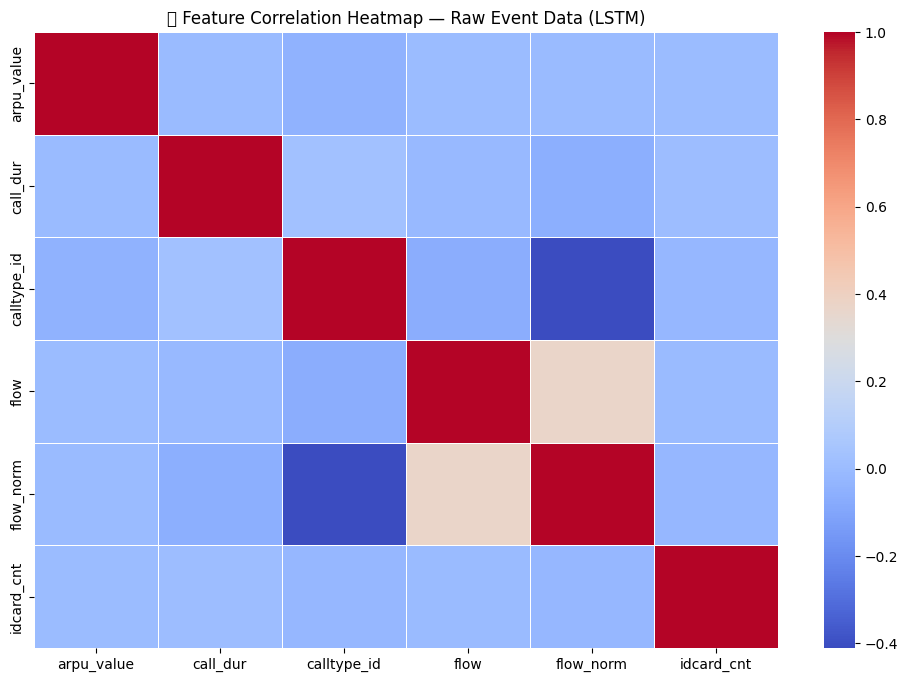

,Feature1,Feature2,Correlation


In [26]:
# --- LSTM correlation ---
print("📊 Correlation Matrix — Raw Event Features (LSTM)")

corr_lstm = pd.DataFrame(events[numeric_cols]).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_lstm, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("📊 Feature Correlation Heatmap — Raw Event Data (LSTM)")
plt.show()

# Optional: Highly correlated pairs

corr_pairs_lstm = (
    corr_lstm.where(np.triu(np.ones(corr_lstm.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs_lstm.columns = ["Feature1", "Feature2", "Correlation"]
high_corr_lstm = corr_pairs_lstm[corr_pairs_lstm["Correlation"].abs() > correlation_threshold]
display(high_corr_lstm)


### NAS LSTM

In [27]:
# ============================================================
# 🔬 NAS FOR LSTM - IDENTICAL TO TIMESNET NAS
# ============================================================
# This script uses the EXACT SAME:
#   - Search space
#   - Pre-seeded trials
#   - Sampler configuration
#   - Evaluation metric (F1 with threshold search)
# as the TimesNet NAS to ensure fair comparison.
#
# USAGE: Run this cell AFTER your data preparation cells
#        (after trans_X_train, trans_X_val, trans_X_test are created)
# ============================================================

import optuna
from optuna.samplers import TPESampler

# ============================================================
# CONFIG - MATCH TIMESNET NAS EXACTLY
# ============================================================
          # Same as TimesNet NAS

# ============================================================
# LSTM MODEL
# ============================================================

class LSTMFraudNAS(nn.Module):
    """LSTM model for NAS"""

    def __init__(self, input_dim, hidden_dim=32, n_layers=4, d_ff=128, dropout=0.3, num_classes=2):
        super().__init__()

        # Handle dropout for single layer
        lstm_dropout = dropout if n_layers > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=lstm_dropout,
            bidirectional=False
        )

        self.cls = nn.Sequential(
            nn.Linear(hidden_dim, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, num_classes)
        )

    def forward(self, x, mask=None):
        lstm_out, (h_n, c_n) = self.lstm(x)
        out = h_n[-1]

        if mask is not None:
            keep = (~mask).unsqueeze(-1).float()
            denom = keep.sum(dim=1).clamp(min=1)
            out = (lstm_out * keep).sum(dim=1) / denom

        logits = self.cls(out)
        return logits


# ============================================================
# SINGLE TRIAL FUNCTION
# ============================================================

def run_lstm_nas_trial(params, X_train, y_train, X_val, y_val, X_test, y_test, device, nas_epochs):
    """
    Train and evaluate one LSTM configuration.
    Returns best F1 score (same metric as TimesNet NAS).
    """

    # Prepare data
    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

    y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
    y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

    def create_mask(X):
        return (X.sum(dim=-1) == 0)

    M_train = create_mask(X_train_t)
    M_val = create_mask(X_val_t)
    M_test = create_mask(X_test_t)

    train_ds = TensorDataset(X_train_t, M_train, y_train_t)
    val_ds = TensorDataset(X_val_t, M_val, y_val_t)
    test_ds = TensorDataset(X_test_t, M_test, y_test_t)

    train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=params["batch_size"], shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False)

    # Create model
    model = LSTMFraudNAS(
        input_dim=X_train.shape[2],
        hidden_dim=params["d_model"],
        n_layers=params["e_layers"],    # Use e_layers (same name as TimesNet)
        d_ff=params["d_ff"],
        dropout=params["dropout"],
        num_classes=2
    ).to(device)

    # Optimizer & Loss (match TimesNet)
    optimizer = torch.optim.RAdam(model.parameters(), lr=params["lr"])
    #criterion = nn.CrossEntropyLoss()
    # ✅ FIX — compute weights from y_train (already passed into the function)
    #neg = (y_train == 0).sum()
    #pos = (y_train == 1).sum()
    #class_weights = torch.tensor(
    #    [1.0, neg / pos],
    #    dtype=torch.float32
    #).to(device)
    #criterion = nn.CrossEntropyLoss(weight=class_weights)
    criterion = nn.CrossEntropyLoss()

    # Training loop with early stopping
    best_val_f1_so_far = 0.0
    patience_counter = 0
    best_model_state = None

    for ep in range(1, nas_epochs + 1):
        # Train
        model.train()
        for xb, mb, yb in train_loader:
            logits = model(xb, mask=mb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=4.0)
            optimizer.step()

        # Validate
        model.eval()
        all_val_probs, all_val_labels = [], []
        with torch.no_grad():
            for xb, mb, yb in val_loader:
                probs = torch.softmax(model(xb, mask=mb), dim=1)[:, 1]
                all_val_probs.extend(probs.cpu().numpy())
                all_val_labels.extend(yb.cpu().numpy())

        all_val_probs = np.array(all_val_probs)
        best_val_f1 = -1.0
        for thr in np.linspace(0.2, 0.8, 61):
            f1 = f1_score(all_val_labels,
                          (all_val_probs >= thr).astype(int),
                          zero_division=0)
            if f1 > best_val_f1:
                best_val_f1 = f1

        if best_val_f1 > best_val_f1_so_far:
            best_val_f1_so_far = best_val_f1
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= params["patience"]:
                break

    # Load best model and evaluate on test set
# ============================================================
# Evaluate best model using VALIDATION threshold
# ============================================================
    if best_model_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})

    # --- Validation probs ---
    model.eval()
    val_probs_list = []
    val_labels_list = []

    with torch.no_grad():
        for xb, mb, yb in val_loader:
            logits = model(xb, mask=mb)
            probs = torch.softmax(logits, dim=1)[:, 1]
            val_probs_list.extend(probs.cpu().numpy())
            val_labels_list.extend(yb.cpu().numpy())

    val_probs = np.array(val_probs_list)
    val_labels = np.array(val_labels_list)

    best_val_thr, best_val_f1 = find_best_threshold(val_labels, val_probs)

    val_preds = (val_probs >= best_val_thr).astype(int)
    val_auc = roc_auc_score(val_labels, val_probs)
    val_recall = recall_score(val_labels, val_preds, zero_division=0)
    val_precision = precision_score(val_labels, val_preds, zero_division=0)

    # --- Test probs ---
    test_probs_list = []
    test_labels_list = []

    with torch.no_grad():
        for xb, mb, yb in test_loader:
            logits = model(xb, mask=mb)
            probs = torch.softmax(logits, dim=1)[:, 1]
            test_probs_list.extend(probs.cpu().numpy())
            test_labels_list.extend(yb.cpu().numpy())

    test_probs = np.array(test_probs_list)
    test_labels = np.array(test_labels_list)

    # Test metrics using VALIDATION threshold
    test_preds = (test_probs >= best_val_thr).astype(int)
    test_f1 = f1_score(test_labels, test_preds, zero_division=0)
    test_auc = roc_auc_score(test_labels, test_probs)
    test_recall = recall_score(test_labels, test_preds, zero_division=0)
    test_precision = precision_score(test_labels, test_preds, zero_division=0)

    # Oracle test threshold for monitoring only
    best_test_threshold, _ = find_best_threshold(test_labels, test_probs)

    return {
        "val_f1": best_val_f1,
        "val_auc": val_auc,
        "val_recall": val_recall,
        "val_precision": val_precision,
        "val_threshold": best_val_thr,
        "test_f1": test_f1,
        "test_auc": test_auc,
        "test_recall": test_recall,
        "test_precision": test_precision,
        "best_test_threshold": best_test_threshold,
    }


# ============================================================
# OPTUNA OBJECTIVE - IDENTICAL SEARCH SPACE AS TIMESNET NAS
# ============================================================

def create_lstm_objective(X_train, y_train, X_val, y_val, X_test, y_test, device, nas_epochs):
    """Factory to create objective with IDENTICAL search space as TimesNet NAS"""

    def objective(trial):
        params = {
            # ✅ IDENTICAL: Same learning rate range as TimesNet NAS
            "lr": trial.suggest_float("lr", 5e-5, 3e-3, log=True),

            # ✅ IDENTICAL: Same d_model range as TimesNet NAS
            "d_model": trial.suggest_categorical("d_model", [2, 4, 8, 16, 32, 48, 64, 128, 256]),

            # ✅ IDENTICAL: Same d_ff range as TimesNet NAS
            "d_ff": trial.suggest_categorical("d_ff", [2, 4, 8, 16, 32, 64, 128, 256, 512]),

            # ✅ IDENTICAL: Same e_layers range as TimesNet NAS
            "e_layers": trial.suggest_int("e_layers", 2, 6),

            # ✅ IDENTICAL: Same dropout range as TimesNet NAS
            "dropout": trial.suggest_float("dropout", 0.0, 0.4),

            # ✅ IDENTICAL: Same batch_size range as TimesNet NAS
            "batch_size": trial.suggest_categorical("batch_size", [ 8, 16]),

            # ✅ IDENTICAL: Same patience range as TimesNet NAS
            "patience": trial.suggest_int("patience", 2, 5)
        }

        # NOTE: top_k is TimesNet-specific (FFT frequency selection)
        # LSTM doesn't have this parameter, so we exclude it

        try:
            eval_out = run_lstm_nas_trial(
                params=params,
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                X_test=X_test,
                y_test=y_test,
                device=device,
                nas_epochs=nas_epochs
            )

            best_val_f1 = eval_out["val_f1"]
            test_f1 = eval_out["test_f1"]
            best_val_thr = eval_out["val_threshold"]
            best_test_threshold = eval_out["best_test_threshold"]
            val_auc = eval_out["val_auc"]
            val_recall = eval_out["val_recall"]
            val_precision = eval_out["val_precision"]
            test_auc = eval_out["test_auc"]
            test_recall = eval_out["test_recall"]
            test_precision = eval_out["test_precision"]

            global best_lstm_f1_so_far, best_lstm_trial_so_far

            if best_val_f1 > best_lstm_f1_so_far:
                best_lstm_f1_so_far = best_val_f1
                best_lstm_trial_so_far = trial.number

            trial_row = {
                "date": datetime.now().strftime("%Y-%m-%d"),
                "time": datetime.now().strftime("%H:%M:%S"),
                "seq_length": max_seq_len,
                "trial_id": trial.number,
                "model": "LSTM",

                # Validation
                "val_f1": round(best_val_f1, 4),
                "val_auc": round(val_auc, 4),
                "val_recall": round(val_recall, 4),
                "val_precision": round(val_precision, 4),

                # Parameters
                "lr": params["lr"],
                "d_model": params["d_model"],
                "d_ff": params["d_ff"],
                "e_layers": params["e_layers"],
                "dropout": params["dropout"],
                "batch_size": params["batch_size"],
                "patience": params["patience"],

                # Thresholds
                "val_threshold": round(best_val_thr, 3),
                "best_test_threshold": round(best_test_threshold, 3),

                # Best tracking
                "best_val_so_far": round(best_lstm_f1_so_far, 4),
                "best_trial_id": best_lstm_trial_so_far,

                # Test (monitoring only)
                "test_f1": round(test_f1, 4),
                "test_auc": round(test_auc, 4),
                "test_recall": round(test_recall, 4),
                "test_precision": round(test_precision, 4),

                # Diagnostics
                "gap_val_test": round(best_val_f1 - test_f1, 4),
                "is_enqueued": trial.number in ENQUEUED_LSTM_IDS,
                "status": "OK",
            }

            lstm_trial_log.append(trial_row)
            display(pd.DataFrame([trial_row]))

            print(f"  Trial {trial.number}: Val F1={best_val_f1:.4f} | Test F1={test_f1:.4f}, val_thr={best_val_thr:.2f}")

            return best_val_f1

        except Exception as e:
            print(f"❌ Trial {trial.number} failed: {e}")

            trial_row = {
                "date": datetime.now().strftime("%Y-%m-%d"),
                "time": datetime.now().strftime("%H:%M:%S"),
                "seq_length": max_seq_len,
                "trial_id": trial.number,
                "model": "LSTM",
                "is_enqueued": trial.number in ENQUEUED_LSTM_IDS,
                "status": f"FAIL: {str(e)}",
            }
            lstm_trial_log.append(trial_row)
            display(pd.DataFrame([trial_row]))

            return 0.0

    return objective


# ============================================================
# 🚀 RUN LSTM NAS
# ============================================================

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n" + "="*60)
print("="*60)
print(f"   Trials: {n_trials_lstm}")
print(f"   Epochs per trial: {nas_epochs}")
print(f"   Train size: {len(trans_X_train)}")
print(f"   Val size: {len(trans_X_val)}")
print(f"   Test size: {len(trans_X_test)}")
print(f"   Features: {trans_X_train.shape[2]}")
print(f"   Seq length: {trans_X_train.shape[1]}")
print(f"   Device: {device}")

# ============================================================
# SAMPLER - IDENTICAL TO TIMESNET NAS
# ============================================================
sampler = TPESampler(
    n_startup_trials=10,      # Same as TimesNet NAS
    n_ei_candidates=24,       # Same as TimesNet NAS
    multivariate=True,        # Same as TimesNet NAS
    seed=42                   # Same as TimesNet NAS
)

study_lstm = optuna.create_study(
    direction="maximize",     # Maximize F1 (same as TimesNet NAS)
    sampler=sampler
    #pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)

# ============================================================
# PRE-SEEDED TRIALS - IDENTICAL TO TIMESNET NAS
# ============================================================

# Trial 1: xs config (best AUC) - IDENTICAL to TimesNet
study_lstm.enqueue_trial({
    "lr": 1e-3,
    "d_model": 4,
    "d_ff": 2,
    "e_layers": 2,
    "dropout": 0.0,
    "batch_size": 8,
    "patience": 3
})

# Trial 2: dxs config (best F1) - IDENTICAL to TimesNet
study_lstm.enqueue_trial({
    "lr": 1e-3,
    "d_model": 4,
    "d_ff": 2,
    "e_layers": 2,
    "dropout": 0.3,
    "batch_size": 8,
    "patience": 3
})

# Trial 3: s config variant - IDENTICAL to TimesNet
study_lstm.enqueue_trial({
    "lr": 1e-4,
    "d_model": 32,
    "d_ff": 32,
    "e_layers": 2,
    "dropout": 0.1,
    "batch_size": 8,
    "patience": 3
})

# Trial 4: Large model config - IDENTICAL to TimesNet
study_lstm.enqueue_trial({
    "lr": 1e-3,
    "d_model": 64,
    "d_ff": 128,
    "e_layers": 3,
    "dropout": 0.2,
    "batch_size": 8,
    "patience": 3
})

# Trial 5: Very small model - IDENTICAL to TimesNet
study_lstm.enqueue_trial({
    "lr": 1e-3,
    "d_model": 2,
    "d_ff": 2,
    "e_layers": 2,
    "dropout": 0.0,
    "batch_size": 16,
    "patience": 3
})

# Trial 6: Additional seed trial - IDENTICAL to TimesNet
study_lstm.enqueue_trial({
    "lr": 0.000936,
    "d_model": 48,
    "d_ff": 4,
    "e_layers": 2,
    "dropout": 0.387,
    "batch_size": 8,
    "patience": 5
})

# ============================================================
# RUN OPTIMIZATION
# ============================================================
lstm_trial_log = []
best_lstm_f1_so_far = -1.0
best_lstm_trial_so_far = -1
ENQUEUED_LSTM_IDS = {0, 1, 2, 3, 4, 5}

objective_lstm = create_lstm_objective(
    X_train=trans_X_train,
    y_train=trans_y_train,
    X_val=trans_X_val,
    y_val=trans_y_val,
    X_test=trans_X_test,
    y_test=trans_y_test,
    device=device,
    nas_epochs=nas_epochs
)

print(f"\n[{datetime.now()}] 🚀 Starting LSTM NAS optimization...")
study_lstm.optimize(objective_lstm, n_trials=n_trials_lstm)

# ============================================================
# RESULTS
# ============================================================
BEST_TRIAL_LSTM = study_lstm.best_trial.number
BEST_PARAMS_LSTM = study_lstm.best_trial.params
BEST_MODEL_ID_LSTM = f"NAS_LSTM_{BEST_TRIAL_LSTM}"

print("\n" + "="*60)
print("🎉 BEST LSTM NAS MODEL FOUND")
print("="*60)
print(f"Model ID: {BEST_MODEL_ID_LSTM}")
print(f"Best F1: {study_lstm.best_value:.4f}")
print(f"Best Params: {BEST_PARAMS_LSTM}")

# ============================================================
# ANALYSIS: ALL TRIALS RANKED BY F1
# ============================================================
print("\n" + "="*60)
print("📊 ALL TRIALS RANKED BY F1")
print("="*60)

trials_df_lstm = study_lstm.trials_dataframe()
trials_df_lstm = trials_df_lstm.sort_values("value", ascending=False)

display_cols = ["number", "value", "params_d_model", "params_d_ff",
                "params_dropout", "params_lr", "params_e_layers"]
available_cols = [c for c in display_cols if c in trials_df_lstm.columns]
print(trials_df_lstm[available_cols].to_string())
print("\n📊 LSTM Trial Log (sorted by val_f1):")
display(
    pd.DataFrame(lstm_trial_log)
    .sort_values("val_f1", ascending=False, na_position="last")
    .reset_index(drop=True)
)
# ============================================================
# ANALYSIS: MODEL SIZE vs PERFORMANCE
# ============================================================
print("\n" + "="*60)
print("📈 MODEL SIZE vs PERFORMANCE ANALYSIS")
print("="*60)

if "params_d_model" in trials_df_lstm.columns:
    size_analysis = trials_df_lstm.groupby("params_d_model")["value"].agg(["mean", "max", "count"])
    size_analysis.columns = ["Avg_F1", "Max_F1", "Trials"]
    size_analysis = size_analysis.sort_index()
    print("\nPerformance by d_model:")
    print(size_analysis.to_string())

# ============================================================
# SAVE RESULTS
# ============================================================
OUT_DIR = os.path.join(config["output"]["results_dir"], "NAS_v2/")
os.makedirs(OUT_DIR, exist_ok=True)
lstm_nas_results_path = f"{OUT_DIR}nas_lstm_results_WL{max_seq_len}.csv"
trials_df_lstm.to_csv(lstm_nas_results_path, index=False)

lstm_trial_log_path = f"{OUT_DIR}nas_lstm_trial_log_WL{max_seq_len}.csv"
pd.DataFrame(lstm_trial_log) \
    .sort_values("val_f1", ascending=False, na_position="last") \
    .to_csv(lstm_trial_log_path, index=False)

print(f"\n💾 Results saved to: {lstm_nas_results_path}")
print(f"💾 Trial log saved to: {lstm_trial_log_path}")
# ============================================================
# COMPARISON WITH TIMESNET NAS
# ============================================================
print("\n" + "="*60)
print("📋 COMPARISON: TimesNet NAS vs LSTM NAS")
print("="*60)

print(f"\n{'Metric':<20} {'TimesNet NAS':<15} {'LSTM NAS':<15}")
print("-" * 50)
print(f"{'Best F1':<20} {'0.8777':<15} {study_lstm.best_value:<15.4f}")
print(f"{'Best Trial':<20} {'96':<15} {BEST_TRIAL_LSTM:<15}")

print(f"\n{'Parameter':<15} {'TimesNet Best':<15} {'LSTM Best':<15}")
print("-" * 45)

timesnet_best = {
    "lr": "NA",
    "d_model": "NA",
    "d_ff": "NA",
    "e_layers": "NA",
    "dropout": "NA",
    "batch_size": "NA",
    "patience": "NA"
}

for k in timesnet_best.keys():
    tn_val = timesnet_best[k]
    lstm_val = BEST_PARAMS_LSTM.get(k, "N/A")
    print(f"{k:<15} {str(tn_val):<15} {str(lstm_val):<15}")

print(f"\n[{datetime.now()}] ✅ LSTM NAS Complete!")

/tmp/ipykernel_2385/1716870077.py:386: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = TPESampler(
[I 2026-07-09 11:34:11,260] A new study created in memory with name: no-name-cd8168db-0199-402f-9110-3afc1dba7bb5



   Trials: 100
   Epochs per trial: 20
   Train size: 3907
   Val size: 977
   Test size: 1222
   Features: 8
   Seq length: 6
   Device: cuda

[2026-07-09 11:34:11.262019] 🚀 Starting LSTM NAS optimization...


,date,time,seq_length,trial_id,model,val_f1,val_auc,val_recall,val_precision,lr,d_model,d_ff,e_layers,dropout,batch_size,patience,val_threshold,best_test_threshold,best_val_so_far,best_trial_id,test_f1,test_auc,test_recall,test_precision,gap_val_test,is_enqueued,status
0,2026-07-09,11:34:39,6,0,LSTM,0.7036,0.8391,0.6879,0.72,0.001,4,2,2,0.0,8,3,0.35,0.33,0.7036,0,0.6913,0.8318,0.6667,0.7178,0.0123,True,OK


[I 2026-07-09 11:34:39,353] Trial 0 finished with value: 0.7035830618892508 and parameters: {'lr': 0.001, 'd_model': 4, 'd_ff': 2, 'e_layers': 2, 'dropout': 0.0, 'batch_size': 8, 'patience': 3}. Best is trial 0 with value: 0.7035830618892508.


  Trial 0: Val F1=0.7036 | Test F1=0.6913, val_thr=0.35


...

,date,time,seq_length,trial_id,model,val_f1,val_auc,val_recall,val_precision,lr,d_model,d_ff,e_layers,dropout,batch_size,patience,val_threshold,best_test_threshold,best_val_so_far,best_trial_id,test_f1,test_auc,test_recall,test_precision,gap_val_test,is_enqueued,status
0,2026-07-09,12:27:23,6,99,LSTM,0.7229,0.8515,0.7102,0.736,0.002714,64,512,2,0.29506,8,5,0.39,0.4,0.7285,21,0.695,0.8454,0.6667,0.7258,0.0279,False,OK


[I 2026-07-09 12:27:23,644] Trial 99 finished with value: 0.7228525121555915 and parameters: {'lr': 0.0027142934654819993, 'd_model': 64, 'd_ff': 512, 'e_layers': 2, 'dropout': 0.29505985571360893, 'batch_size': 8, 'patience': 5}. Best is trial 21 with value: 0.7284768211920529.


  Trial 99: Val F1=0.7229 | Test F1=0.6950, val_thr=0.39

🎉 BEST LSTM NAS MODEL FOUND
Model ID: NAS_LSTM_21
Best F1: 0.7285
Best Params: {'lr': 0.0026408158713451366, 'd_model': 16, 'd_ff': 32, 'e_layers': 3, 'dropout': 0.3002558034760724, 'batch_size': 8, 'patience': 5}

📊 ALL TRIALS RANKED BY F1
    number     value  params_d_model  params_d_ff  params_dropout  params_lr  params_e_layers
21      21  0.728477              16           32        0.300256   0.002641                3
46      46  0.727580              16          512        0.249610   0.002708                3
12      12  0.727273              48            2        0.258573   0.002575                4
63      63  0.726962              16          512        0.339801   0.002874                2
41      41  0.726027             128           32        0.269212   0.002076                2
49      49  0.724919              16           64        0.215049   0.001641                5
24      24  0.724490              64       

,date,time,seq_length,trial_id,model,val_f1,val_auc,val_recall,val_precision,lr,d_model,d_ff,e_layers,dropout,batch_size,patience,val_threshold,best_test_threshold,best_val_so_far,best_trial_id,test_f1,test_auc,test_recall,test_precision,gap_val_test,is_enqueued,status
0,2026-07-09,11:45:03,6,21,LSTM,0.7285,0.8511,0.7006,0.7586,0.002641,16,32,3,0.300256,8,5,0.34,0.26,0.7285,21,0.6946,0.8466,0.6539,0.7406,0.0339,False,OK
1,2026-07-09,11:58:11,6,46,LSTM,0.7276,0.8556,0.6847,0.7762,0.002708,16,512,3,0.249610,8,5,0.41,0.32,0.7285,21,0.6860,0.8482,0.6310,0.7515,0.0415,False,OK
2,2026-07-09,11:39:56,6,12,LSTM,0.7273,0.8505,0.7006,0.7560,0.002575,48,2,4,0.258573,8,5,0.37,0.35,0.7273,12,0.6996,0.8458,0.6489,0.7589,0.0277,False,OK
3,2026-07-09,12:08:55,6,63,LSTM,0.7270,0.8534,0.6783,0.7831,0.002874,16,512,2,0.339801,8,5,0.55,0.29,0.7285,21,0.6844,0.8487,0.6209,0.7625,0.0425,False,OK
4,2026-07-09,11:55:08,6,41,LSTM,0.7260,0.8454,0.6752,0.7852,0.002076,128,32,2,0.269212,8,5,0.56,0.54,0.7285,21,0.6982,0.8452,0.6387,0.7699,0.0278,False,OK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2026-07-09,11:35:04,6,1,LSTM,0.6890,0.8351,0.6879,0.6901,0.001000,4,2,2,0.300000,8,3,0.24,0.25,0.7036,0,0.6737,0.8146,0.6514,0.6975,0.0153,True,OK
96,2026-07-09,11:50:01,6,33,LSTM,0.6834,0.8246,0.6497,0.7208,0.000792,2,32,2,0.380850,8,4,0.30,0.24,0.7285,21,0.6685,0.8188,0.6310,0.7106,0.0150,False,OK
97,2026-07-09,11:44:23,6,20,LSTM,0.6505,0.7959,0.6401,0.6612,0.000281,2,2,4,0.240949,8,5,0.26,0.27,0.7273,12,0.6385,0.7964,0.6336,0.6434,0.0120,False,OK
98,2026-07-09,11:37:52,6,8,LSTM,0.4864,0.4934,1.0000,0.3214,0.000469,4,32,6,0.029820,8,2,0.20,0.20,0.7191,5,0.4867,0.4855,1.0000,0.3216,-0.0002,False,OK



📈 MODEL SIZE vs PERFORMANCE ANALYSIS

Performance by d_model:
                  Avg_F1    Max_F1  Trials
params_d_model                            
2               0.659292  0.708117       7
4               0.677625  0.719328       8
8               0.713253  0.720000       5
16              0.715613  0.728477      20
32              0.712874  0.720930       7
48              0.717377  0.727273      14
64              0.715692  0.724490      13
128             0.717021  0.726027      20
256             0.714304  0.722689       6

💾 Results saved to: /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/results/NAS_v2/nas_lstm_results_WL6.csv
💾 Trial log saved to: /content/drive/MyDrive/Sem-6/coding/github/fraud_detection/results/NAS_v2/nas_lstm_trial_log_WL6.csv

📋 COMPARISON: TimesNet NAS vs LSTM NAS

Metric               TimesNet NAS    LSTM NAS       
--------------------------------------------------
Best F1              0.8777          0.7285         
Best Trial           96

#freeze

In [28]:
%pip freeze > "{project_path}requirement/freez/LSTM_NASEnhancedPretraindMLModleAdvance-lock.txt"

In [29]:
end = time.time()
elapsed = end - start_time

hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)

print(f"Total Time = {hours}h {minutes}m {seconds}s")

Total Time = 0h 57m 46s
